In [ ]:
import pandas as pd

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 读取文件并提取数据
def extract_reward_data(filename):
    """
    从文件中提取step和reward数据
    """
    steps = []
    rewards = []
    grads = []
    
    # 使用正则表达式匹配需要的行
    pattern = r'\[Step (\d+)/\d+\] reward=([0-9.]+), grad=([0-9.]+)'
    
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            match = re.search(pattern, line)
            if match:
                step = int(match.group(1))
                reward = float(match.group(2))
                grad = float(match.group(3))
                
                steps.append(step)
                rewards.append(reward)
                grads.append(grad)
    
    return steps, rewards, grads

def plot_reward_curve(steps, rewards, grads=None):
    """
    绘制reward随step变化的曲线
    """
    # 创建图形，设置中文字体
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号
    
    if grads:
        # 如果有grad数据，创建两个子图
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # 绘制reward曲线
        ax1.plot(steps, rewards, 'b-o', markersize=4, linewidth=1.5, label='Reward')
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Reward')
        ax1.set_title('Reward with step')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # 绘制grad曲线
        ax2.plot(steps, grads, 'r-s', markersize=4, linewidth=1.5, label='Grad')
        ax2.set_xlabel('Step')
        ax2.set_ylabel('Grad')
        ax2.set_title('Grad with step')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
    else:
        # 只绘制reward曲线
        plt.figure(figsize=(10, 6))
        plt.plot(steps, rewards, 'b-o', markersize=4, linewidth=1.5, label='Reward')
        plt.xlabel('Step')
        plt.ylabel('Reward')
        plt.title('Reward with step')
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# 指定输入文件名（请修改为你的实际文件名）
input_file = 'logs/checkpoints_math500_num_generation8_t0.3.log'  # 请替换为实际文件名


# 提取数据
steps, rewards, grads = extract_reward_data(input_file)

# 打印统计信息
print(f"找到 {len(steps)} 条数据记录")
print(f"Step 范围: {min(steps)} - {max(steps)}")
print(f"Reward 范围: {min(rewards):.4f} - {max(rewards):.4f}")
print(f"平均 Reward: {np.mean(rewards):.4f}")
print(f"Reward 标准差: {np.std(rewards):.4f}")

if grads:
    print(f"\nGrad 范围: {min(grads):.4f} - {max(grads):.4f}")
    print(f"平均 Grad: {np.mean(grads):.4f}")

# 绘制曲线
plot_reward_curve(steps, rewards, grads)

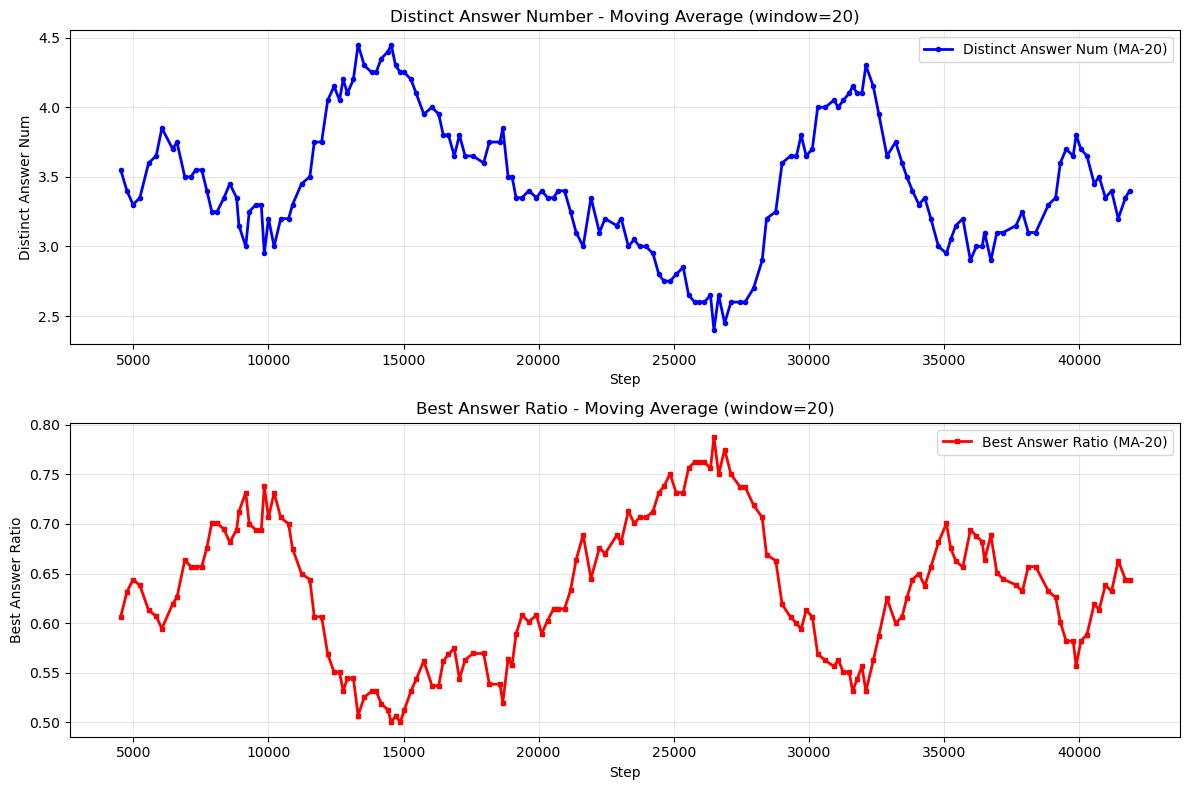

Data Analysis with Moving Average (window=20)
Total data points: 185
After moving average: 166 points

Distinct Answer Num:
  Original - Range: [1, 8], Mean: 3.44
  MA-20 - Range: [2.40, 4.45], Mean: 3.45

Best Answer Ratio:
  Original - Range: [0.120, 1.000], Mean: 0.633
  MA-20 - Range: [0.500, 0.787], Mean: 0.631


In [8]:
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def extract_diversity_data(filename):
    """
    从文件中提取diversity数据
    """
    steps = []
    distinct_answer_num = []
    best_answer_ratio = []
    
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*best_answer_ratio:\s*([0-9.]+)'
    
    with open(filename, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            match = re.search(pattern, line)
            if match:
                steps.append(line_num)
                distinct_answer_num.append(int(match.group(1)))
                best_answer_ratio.append(float(match.group(2)))
    
    return steps, distinct_answer_num, best_answer_ratio

def moving_average(data, window_size=5):
    """计算滑动平均"""
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

def plot_with_moving_average(steps, distinct_answer_num, best_answer_ratio, window_size=5):
    """
    绘制两个图表，都使用滑动平均
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # 计算滑动平均
    ma_distinct = moving_average(distinct_answer_num, window_size)
    ma_best = moving_average(best_answer_ratio, window_size)
    ma_steps = steps[window_size-1:]
    
    # 图1: distinct_answer_num with moving average
    ax1.plot(ma_steps, ma_distinct, 'b-', linewidth=2, marker='o', markersize=3, 
             label=f'Distinct Answer Num (MA-{window_size})')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Distinct Answer Num')
    ax1.set_title(f'Distinct Answer Number - Moving Average (window={window_size})')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 图2: best_answer_ratio with moving average
    ax2.plot(ma_steps, ma_best, 'r-', linewidth=2, marker='s', markersize=3,
             label=f'Best Answer Ratio (MA-{window_size})')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Best Answer Ratio')
    ax2.set_title(f'Best Answer Ratio - Moving Average (window={window_size})')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"{'='*50}")
    print(f"Data Analysis with Moving Average (window={window_size})")
    print(f"{'='*50}")
    print(f"Total data points: {len(steps)}")
    print(f"After moving average: {len(ma_steps)} points")
    print(f"\nDistinct Answer Num:")
    print(f"  Original - Range: [{min(distinct_answer_num)}, {max(distinct_answer_num)}], Mean: {np.mean(distinct_answer_num):.2f}")
    print(f"  MA-{window_size} - Range: [{min(ma_distinct):.2f}, {max(ma_distinct):.2f}], Mean: {np.mean(ma_distinct):.2f}")
    print(f"\nBest Answer Ratio:")
    print(f"  Original - Range: [{min(best_answer_ratio):.3f}, {max(best_answer_ratio):.3f}], Mean: {np.mean(best_answer_ratio):.3f}")
    print(f"  MA-{window_size} - Range: [{min(ma_best):.3f}, {max(ma_best):.3f}], Mean: {np.mean(ma_best):.3f}")
    print(f"{'='*50}")

# 指定输入文件名
input_file = '/Users/mc03002/Documents/JustGRPO/logs/checkpoints_math500_num_generation8_t0.3.log'  # 请替换为实际文件名


# 提取数据
steps, distinct_answer_num, best_answer_ratio = extract_diversity_data(input_file)

# 设置滑动窗口大小
window_size = 20  # 可以修改这个值来调整平滑程度

# 绘制带滑动平均的图表
plot_with_moving_average(steps, distinct_answer_num, best_answer_ratio, window_size)
